In [7]:
import pandas as pd

jobs = pd.read_csv(r"Skill_Gap_Analyzer/job_roles.csv")
jobs.head()

,role,skills
0,Data Analyst,"Python,SQL,Excel,Power BI,Statistics"
1,Data Scientist,"Python,SQL,Pandas,NumPy,Machine Learning,Stati..."
2,ML Engineer,"Python,TensorFlow,Deep Learning,Docker,AWS"
3,Business Analyst,"Excel,SQL,Power BI,Communication"
4,Software Developer,"Java,Python,SQL,Git"


In [7]:
import pandas as pd

jobs = pd.read_csv(r"Skill_Gap_Analyzer/job_roles.csv")
jobs.head()

,role,skills
0,Data Analyst,"Python,SQL,Excel,Power BI,Statistics"
1,Data Scientist,"Python,SQL,Pandas,NumPy,Machine Learning,Stati..."
2,ML Engineer,"Python,TensorFlow,Deep Learning,Docker,AWS"
3,Business Analyst,"Excel,SQL,Power BI,Communication"
4,Software Developer,"Java,Python,SQL,Git"


In [7]:
import pandas as pd

jobs = pd.read_csv(r"Skill_Gap_Analyzer/job_roles.csv")
jobs.head()

,role,skills
0,Data Analyst,"Python,SQL,Excel,Power BI,Statistics"
1,Data Scientist,"Python,SQL,Pandas,NumPy,Machine Learning,Stati..."
2,ML Engineer,"Python,TensorFlow,Deep Learning,Docker,AWS"
3,Business Analyst,"Excel,SQL,Power BI,Communication"
4,Software Developer,"Java,Python,SQL,Git"


In [8]:
import pandas as pd

jobs = pd.read_csv("Skill_Gap_Analyzer/job_roles.csv")

jobs

,role,skills
0,Data Analyst,"Python,SQL,Excel,Power BI,Statistics"
1,Data Scientist,"Python,SQL,Pandas,NumPy,Machine Learning,Stati..."
2,ML Engineer,"Python,TensorFlow,Deep Learning,Docker,AWS"
3,Business Analyst,"Excel,SQL,Power BI,Communication"
4,Software Developer,"Java,Python,SQL,Git"
5,AI Engineer,"Python,Deep Learning,NLP,TensorFlow"
6,Data Engineer,"Python,SQL,ETL,Spark,Hadoop,AWS"
7,BI Developer,"SQL,Power BI,Excel,Data Modeling,DAX"
8,Cloud Engineer,"AWS,Python,Linux,Docker,Kubernetes"
9,DevOps Engineer,"Linux,Docker,Kubernetes,AWS,Git,Python"


In [6]:
import fitz

pdf_path = "Skill_Gap_Analyzer/resumes/Bipasha_A_resume (1).pdf"

doc = fitz.open(pdf_path)

resume_text = ""

for page in doc:
    resume_text += page.get_text()

print(resume_text)

FileNotFoundError: no such file: 'Skill_Gap_Analyzer/resumes/Bipasha_A_resume (1).pdf'

In [5]:
skills_db = [
    "python",
    "sql",
    "excel",
    "power bi",
    "statistics",
    "pandas",
    "numpy",
    "machine learning",
    "nlp",
    "tensorflow",
    "deep learning",
    "aws",
    "docker",
    "java",
    "git",
    "communication"
]

In [11]:
def extract_skills(text):

    text = text.lower()

    found_skills = []

    for skill in skills_db:
        if skill in text:
            found_skills.append(skill)

    return list(set(found_skills))

In [12]:
user_skills = extract_skills(resume_text)

print("Detected Skills:")
print(user_skills)

Detected Skills:
['numpy', 'excel', 'git', 'python', 'sql', 'pandas', 'power bi']


In [13]:
def predict_role(user_skills):

    scores = {}

    for _, row in jobs.iterrows():

        role = row["role"]

        required = [
            x.strip().lower()
            for x in row["skills"].split(",")
        ]

        matched = set(user_skills) & set(required)

        score = (len(matched) / len(required)) * 100

        scores[role] = round(score, 2)

    best_role = max(scores, key=scores.get)

    return best_role, scores

In [14]:
best_role, scores = predict_role(user_skills)

print("Predicted Career:", best_role)

print("\nCareer Scores:")

for role, score in scores.items():
    print(role, ":", score, "%")

Predicted Career: Data Analyst

Career Scores:
Data Analyst : 80.0 %
Data Scientist : 57.14 %
ML Engineer : 20.0 %
Business Analyst : 75.0 %
Software Developer : 75.0 %
AI Engineer : 25.0 %
Data Engineer : 33.33 %
BI Developer : 60.0 %
Cloud Engineer : 20.0 %
DevOps Engineer : 33.33 %
Database Administrator : 20.0 %
Cybersecurity Analyst : 20.0 %
NLP Engineer : 20.0 %
Computer Vision Engineer : 20.0 %
Product Analyst : 80.0 %
Marketing Analyst : 80.0 %
Financial Analyst : 60.0 %
QA Automation Engineer : 60.0 %
Python Developer : 60.0 %
Java Developer : 40.0 %


In [15]:
def find_skill_gap(user_skills, role):

    row = jobs[jobs["role"] == role].iloc[0]

    required = [
        x.strip().lower()
        for x in row["skills"].split(",")
    ]

    missing = set(required) - set(user_skills)

    return list(missing)

In [16]:
missing_skills = find_skill_gap(
    user_skills,
    best_role
)

print("Target Career:", best_role)

print("\nMissing Skills:")

for skill in missing_skills:
    print("❌", skill)

Target Career: Data Analyst

Missing Skills:
❌ statistics


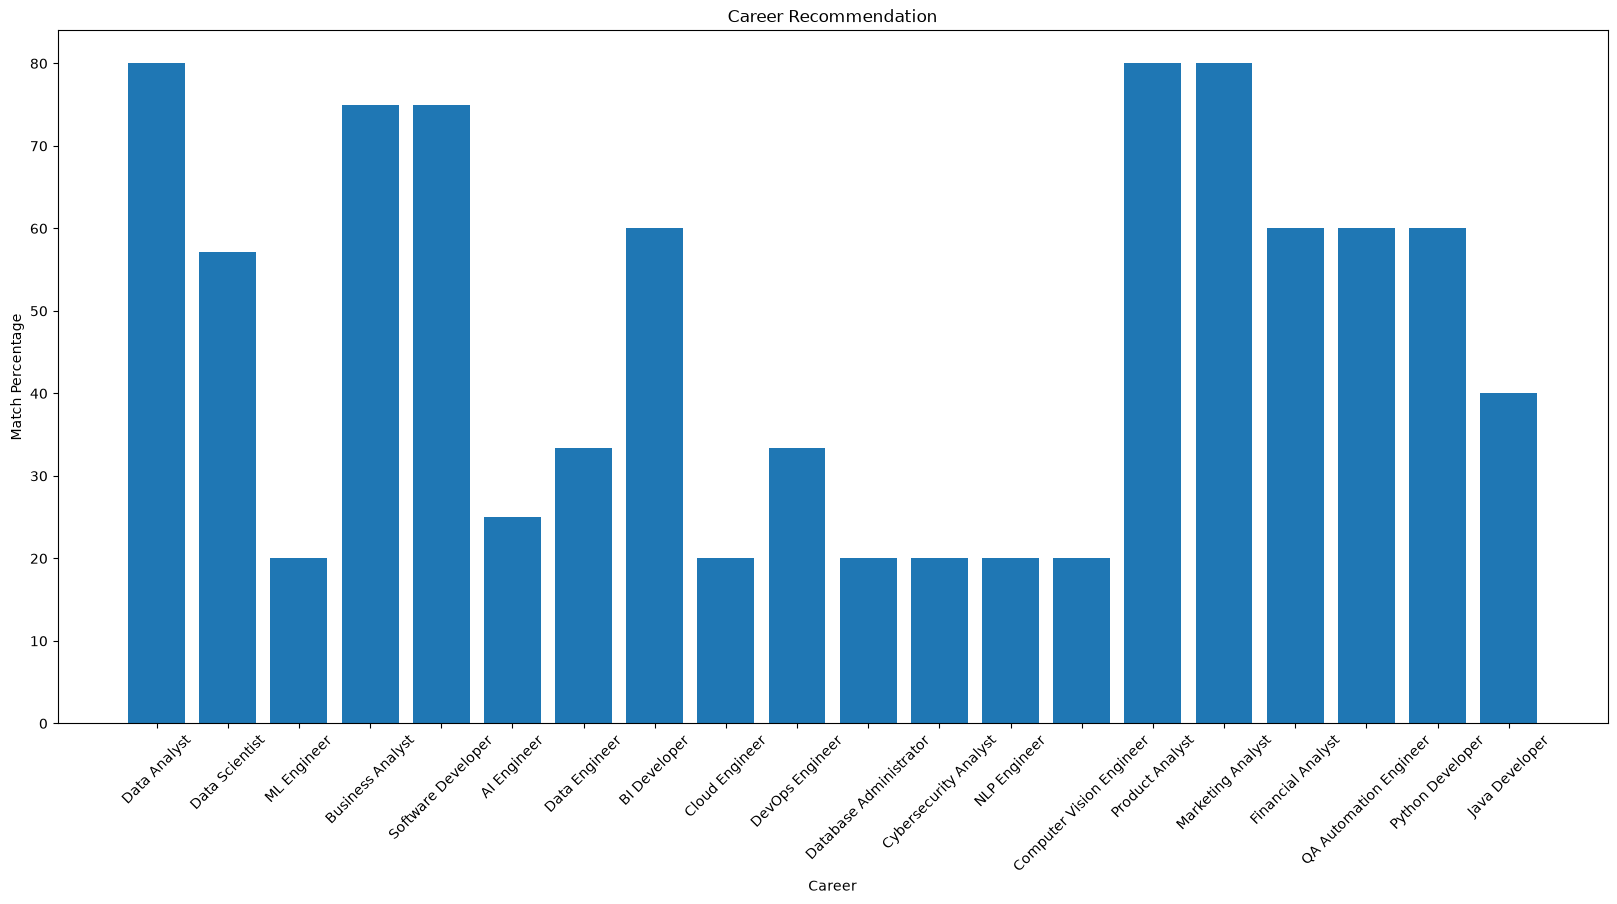

In [18]:
import matplotlib.pyplot as plt

roles = list(scores.keys())
values = list(scores.values())

plt.figure(figsize=(20,9))

plt.bar(roles, values)

plt.xlabel("Career")
plt.ylabel("Match Percentage")
plt.title("Career Recommendation")

plt.xticks(rotation=45)

plt.show()